# Chemical reaction networks


<div class="note"><span class="note-t">TL;DR</span>
<p>We map molecule counts onto a single-token CTMC to run two mass-action reactions in Torx: irreversible combustion runs toward completion and reversible binding relaxes to mass-action equilibrium. We check both sample means against the exact matrix exponential and a Gillespie simulation.</p>
</div>

In this tutorial, we run two mass-action reaction networks in Torx by mapping their count dynamics onto a continuous-time Markov chain carrying a single token (one occupied bit hopping between one-hot configurations). The irreversible water reaction $2\,\mathrm{H_2} + \mathrm{O_2} \to 2\,\mathrm{H_2O}$ fires in a single direction until a reactant is exhausted, so its counts run toward completion. The reversible binding $\mathrm{A} + \mathrm{B} \rightleftharpoons \mathrm{C}$ runs forward and backward at once, so its counts settle into a mass-action equilibrium.

A chemical reaction network is a continuous-time Markov chain on molecule counts. A reaction like $2\,\mathrm{H_2} + \mathrm{O_2} \to 2\,\mathrm{H_2O}$ has two features a single hopping excitation cannot express: it consumes and produces several molecules at once (stoichiometry), and its rate is nonlinear in the counts (mass action, $a = c\,\binom{n_{\mathrm{H_2}}}{2}\,n_{\mathrm{O_2}}$).

The key step is to enumerate the reachable **count configurations**. Each reaction event moves the whole system from one configuration to another, and the nonlinear propensity becomes that edge's rate. The network is then a single token walking on a directed configuration graph, so one `PJUMP` per edge applies, exactly as in a [graph random walk](02_random_walks_on_graphs.ipynb).

We assume basic familiarity with continuous-time Markov chains and JAX. The code uses Torx, JAX, NumPy, and SciPy. By the end, you'll be able to:

- enumerate the reachable molecule-count configurations of a reaction network,
- map each reaction's nonlinear mass-action propensity onto a `PJUMP` edge rate, and
- check the Torx sample mean against the exact CTMC ($e^{Q t}$) and a Gillespie simulation.



## Setup

We configure the helper path, the shared plotting style, and the `savefig` utility used throughout the notebook.

In [1]:
from pathlib import Path
import sys
from math import comb, exp, log


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm

from torx.psc import DiscretePCircuit, PJUMP, SampleSimulator



In [3]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [4]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _nb05_crn import plot_species_dynamics
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
    EXACT_COLOR,
    TORX_COLOR,
    EXTROPIC_GOLD,
)

In [5]:
FIGURE_DIR = figure_dir(ROOT)
SEED = 0
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)




Over a time slice `dt`, a CTMC edge with rate $r$ fires with probability $1 - e^{-r\,dt}$. The `pjump_prob` function below computes that probability, and `PJUMP` reads it through a logit.

In [6]:
def pjump_prob(rate, dt):
    # Exact local CTMC kernel for one directed edge over one slice.
    return 1.0 - exp(-rate * dt)

## The reaction and its configuration space

Start from four $\mathrm{H_2}$ and two $\mathrm{O_2}$. The single reaction can fire until either reactant runs out, so the reachable configurations form a short chain. The mass-action propensity drops sharply as $\mathrm{H_2}$ is consumed.

In [7]:
H2, O2, H2O = 0, 1, 2
species = ["H2", "O2", "H2O"]
# reaction: 2 H2 + O2 -> 2 H2O, with mass-action rate constant c
reactants = {H2: 2, O2: 1}
products = {H2O: 2}
c = 0.10
initial = (4, 2, 0)




Three small functions describe the reaction: the mass-action propensity of a configuration, the state update when the reaction fires, and a search that collects every reachable configuration.

In [8]:
def propensity(state):
    a = c
    for s, nu in reactants.items():
        a *= comb(int(state[s]), nu)
    return a




In [9]:
def apply_reaction(state):
    """Return the configuration after one firing of the reaction."""
    out = list(state)
    for s, nu in reactants.items():
        out[s] -= nu
    for s, nu in products.items():
        out[s] += nu
    return tuple(out)




In [10]:
def reachable(initial):
    """Enumerate every configuration reachable from `initial` by repeated firings."""
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        if all(s[k] >= nu for k, nu in reactants.items()):
            nxt = apply_reaction(s)
            if nxt not in seen:
                seen.add(nxt); frontier.append(nxt)
    return sorted(seen)




In [11]:
configs = reachable(initial)
index = {c2: i for i, c2 in enumerate(configs)}
config_edges = [
    (index[s], index[apply_reaction(s)], propensity(s))
    for s in configs if all(s[k] >= nu for k, nu in reactants.items())
]
print("reachable configurations:", configs)
for i, j, rate in config_edges:
    print(f"  {configs[i]} -> {configs[j]}   propensity = {rate:.3f}")

reachable configurations: [(0, 0, 4), (2, 1, 2), (4, 2, 0)]
  (2, 1, 2) -> (0, 0, 4)   propensity = 0.100
  (4, 2, 0) -> (2, 1, 2)   propensity = 1.200


<div class="note"><span class="note-t">Mass-action rates</span>
<p>From the initial configuration $(4, 2, 0)$ the reaction fires at $c\,\binom{4}{2}\binom{2}{1} = 1.2$; after one firing, from $(2, 1, 2)$, the propensity drops to $c\,\binom{2}{2}\binom{1}{1} = 0.1$. The twelve-fold drop is the nonlinearity that separates a reaction network from a plain random walk.</p>
</div>

## Dynamics: Torx against two references

We compare three trajectories of the expected molecule counts: the exact $e^{Qt}p_0$ on the configuration generator, a Gillespie stochastic simulation on the raw counts (the classical exact stochastic simulation algorithm for coupled chemical reactions; Gillespie 1977), and the Torx sample mean from circuits built at a few repetition counts (snapshots in time).

In [12]:
def ctmc_reference(n_configs, config_edges, p0, times):
    Q = np.zeros((n_configs, n_configs))
    for i, j, rate in config_edges:
        Q[j, i] += rate
        Q[i, i] -= rate
    return np.stack([expm(Q * t) @ p0 for t in times]), Q




In [13]:
def to_counts(dist, configs):
    """Project a distribution over configurations onto expected molecule counts."""
    return dist @ np.array(configs, dtype=float)




In [14]:
def gillespie_mean(times, n_traj, rng):
    """Average `n_traj` Gillespie trajectories on the fixed time grid `times`."""
    acc = np.zeros((len(times), len(species)))
    for _ in range(n_traj):
        state = np.array(initial); t = 0.0; idx = 0; rec = np.zeros((len(times), len(species)))
        while idx < len(times):
            a = propensity(state) if all(state[k] >= nu for k, nu in reactants.items()) else 0.0
            if a <= 0:
                while idx < len(times): rec[idx] = state; idx += 1
                break
            tau = rng.exponential(1.0 / a)
            while idx < len(times) and times[idx] < t + tau: rec[idx] = state; idx += 1
            state = np.array(apply_reaction(tuple(state))); t += tau
        acc += rec
    return acc / n_traj




Evaluate both references on a shared time grid, starting with all the probability on the initial configuration.

In [15]:
T, N = 12.0, 240
dt = T / N
times = np.linspace(0.0, T, N + 1)
p0 = np.zeros(len(configs)); p0[index[initial]] = 1.0

ref_dist, Q = ctmc_reference(len(configs), config_edges, p0, times)
ref_counts = to_counts(ref_dist, configs)
gillespie_counts = gillespie_mean(times, 20_000, np.random.default_rng(SEED))



The Torx circuit places one `PJUMP` on each configuration edge, with parameter $\mathrm{logit}(1 - e^{-r\,dt})$ for that edge's rate $r$. Sampling the circuit at a few repetition counts gives the count distribution at those snapshot times.

In [16]:
gates = [PJUMP([i, j]) for i, j, r in config_edges]
thetas = [jnp.array([logit(pjump_prob(r, dt))]) for i, j, r in config_edges]
init_bits = jnp.zeros(len(configs), dtype=jnp.int32).at[index[initial]].set(1)
snapshot_reps = np.arange(0, N + 1, 24, dtype=int)
snapshot_times = snapshot_reps * dt
sim = SampleSimulator(num_samples=20_000)
keys = jax.random.split(jax.random.key(SEED), len(snapshot_reps))

torx_dist = []
for reps, key in zip(snapshot_reps, keys):
    compiled = sim.build_circuit(DiscretePCircuit(gates, reps=int(reps)), thetas)
    torx_dist.append(np.asarray(sim.sample(compiled, init_bits, key)).mean(axis=0))
torx_counts = to_counts(np.stack(torx_dist), configs)
print("sampled", len(snapshot_reps), "snapshot circuits")

sampled 11 snapshot circuits


Plot the expected counts from all three methods together.

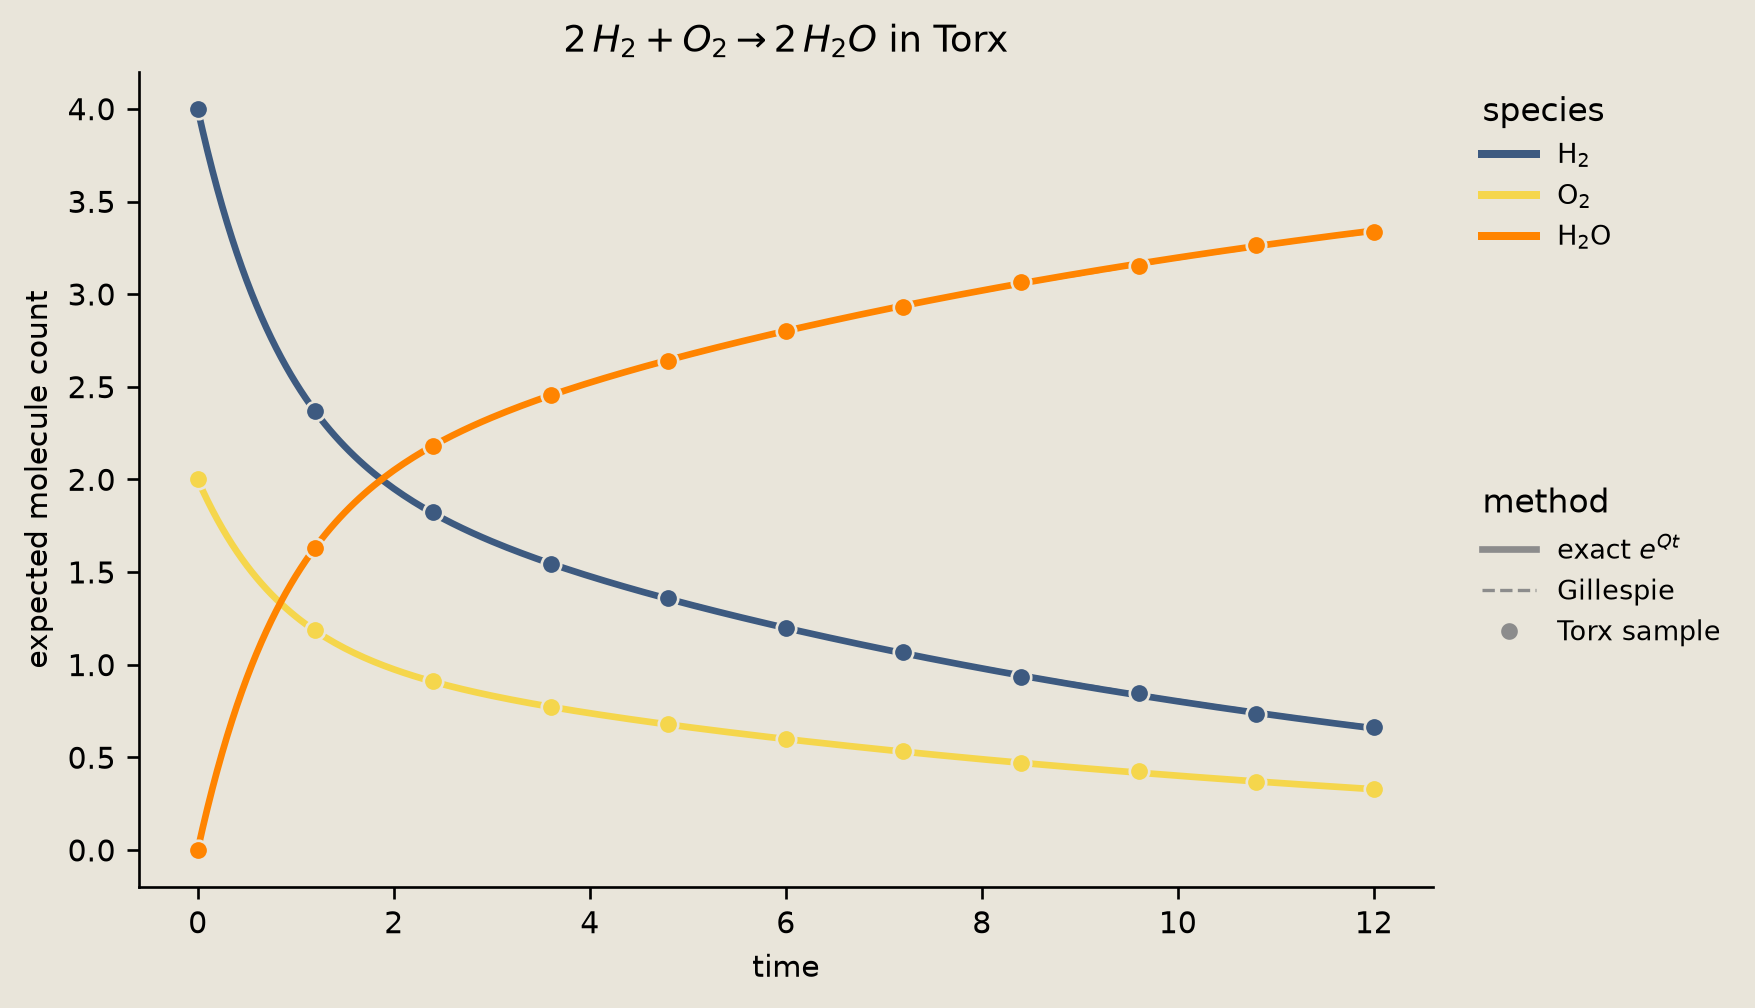

In [17]:
series = [
    (r"$\mathrm{H_2}$", H2, EXACT_COLOR),
    (r"$\mathrm{O_2}$", O2, EXTROPIC_GOLD),
    (r"$\mathrm{H_2O}$", H2O, TORX_COLOR),
]
fig = plot_species_dynamics(
    r"$2\,H_2 + O_2 \rightarrow 2\,H_2O$ in Torx",
    times, ref_counts, gillespie_counts, snapshot_times, torx_counts, series,
)
savefig(fig, "05_crn_dynamics")

The three methods agree across the whole trajectory. $\mathrm{H_2}$ and $\mathrm{O_2}$ are consumed as $\mathrm{H_2O}$ builds up. The reaction slows as the reactants are depleted, because the mass-action propensity falls with the reactant counts. The final firing is the slowest, so the plotted window ends just short of full absorption.

## Verification

Atoms balance across every reaction edge, and the Torx sample mean matches both the exact matrix exponential and the Gillespie simulation.

In [18]:
atoms = {"H": np.array([2, 0, 2]), "O": np.array([0, 2, 1])}
for i, j, _ in config_edges:
    for w in atoms.values():
        assert w @ np.array(configs[i]) == w @ np.array(configs[j])

torx_vs_exact = float(np.max(np.abs(torx_counts - ref_counts[snapshot_reps])))
gil_vs_exact = float(np.max(np.abs(gillespie_counts[snapshot_reps] - ref_counts[snapshot_reps])))
assert torx_vs_exact < 0.05 and gil_vs_exact < 0.05
print(f"atom conservation (H, O)       : OK")
print(f"max |Torx - exact|             : {torx_vs_exact:.4f}  (< 0.05)")
print(f"max |Gillespie - exact|        : {gil_vs_exact:.4f}  (< 0.05)")
print("all checks passed")

atom conservation (H, O)       : OK
max |Torx - exact|             : 0.0132  (< 0.05)
max |Gillespie - exact|        : 0.0065  (< 0.05)
all checks passed


## A reversible reaction: binding equilibrium

The water reaction above is irreversible: it fires in one direction until a reactant runs out, so the molecule counts run to completion. Binding behaves differently. The reaction $\mathrm{A} + \mathrm{B} \rightleftharpoons \mathrm{C}$ has a forward step $\mathrm{A} + \mathrm{B} \to \mathrm{C}$ with propensity $k_f\,n_{\mathrm{A}}\,n_{\mathrm{B}}$ and a reverse step $\mathrm{C} \to \mathrm{A} + \mathrm{B}$ with propensity $k_r\,n_{\mathrm{C}}$. With both directions active the network never absorbs; it relaxes to a mass-action equilibrium where the forward and reverse fluxes balance. The construction is unchanged, one `PJUMP` per directed configuration edge, except the configuration graph now carries edges in both directions.

Two reactions now, forward and reverse, each with its own rate constant. The propensity and update helpers take the reaction as an argument, generalizing the single-reaction versions above.

In [19]:
A, B, C = 0, 1, 2
species = ["A", "B", "C"]
# two reactions: forward binding A + B -> C (kf), reverse C -> A + B (kr)
kf, kr = 0.18, 0.55
reactions = [
    ({A: 1, B: 1}, {C: 1}, kf),   # forward:  a = kf * nA * nB
    ({C: 1}, {A: 1, B: 1}, kr),   # reverse:  a = kr * nC
]
initial = (4, 4, 0)




In [20]:
def propensity(state, reac, rate):
    """Mass-action propensity of reaction `reac` at `state`."""
    a = rate
    for s, nu in reac.items():
        a *= comb(int(state[s]), nu)
    return a




In [21]:
def apply_reaction(state, reac, prod):
    """Return the configuration after one firing of the (`reac`, `prod`) reaction."""
    out = list(state)
    for s, nu in reac.items():
        out[s] -= nu
    for s, nu in prod.items():
        out[s] += nu
    return tuple(out)




In [22]:
def reachable(initial):
    """Enumerate every configuration reachable from `initial` under all reactions."""
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        for reac, prod, rate in reactions:
            if all(s[k] >= nu for k, nu in reac.items()):
                nxt = apply_reaction(s, reac, prod)
                if nxt not in seen:
                    seen.add(nxt); frontier.append(nxt)
    return sorted(seen)




Enumerating the reachable configurations now follows both directions, so the configuration graph carries forward and reverse edges.

In [23]:
configs_b = reachable(initial)
index_b = {c2: i for i, c2 in enumerate(configs_b)}
edges_b = [
    (index_b[s], index_b[apply_reaction(s, reac, prod)], propensity(s, reac, rate))
    for s in configs_b for reac, prod, rate in reactions
    if all(s[k] >= nu for k, nu in reac.items())
]
print("reachable configurations:", configs_b)
for i, j, rate in edges_b:
    print(f"  {configs_b[i]} -> {configs_b[j]}   propensity = {rate:.3f}")

reachable configurations: [(0, 0, 4), (1, 1, 3), (2, 2, 2), (3, 3, 1), (4, 4, 0)]
  (0, 0, 4) -> (1, 1, 3)   propensity = 2.200
  (1, 1, 3) -> (0, 0, 4)   propensity = 0.180
  (1, 1, 3) -> (2, 2, 2)   propensity = 1.650
  (2, 2, 2) -> (1, 1, 3)   propensity = 0.720
  (2, 2, 2) -> (3, 3, 1)   propensity = 1.100
  (3, 3, 1) -> (2, 2, 2)   propensity = 1.620
  (3, 3, 1) -> (4, 4, 0)   propensity = 0.550
  (4, 4, 0) -> (3, 3, 1)   propensity = 2.880


The Gillespie step now chooses which reaction fires, with probability proportional to each reaction's propensity.

In [24]:
def gillespie_b(times, n_traj, rng):
    acc = np.zeros((len(times), len(species)))
    for _ in range(n_traj):
        state = np.array(initial); t = 0.0; idx = 0; rec = np.zeros((len(times), len(species)))
        while idx < len(times):
            props = np.array([propensity(state, reac, rate) if all(state[k] >= nu for k, nu in reac.items()) else 0.0
                              for reac, prod, rate in reactions])
            a0 = props.sum()
            if a0 <= 0:
                while idx < len(times): rec[idx] = state; idx += 1
                break
            tau = rng.exponential(1.0 / a0)
            while idx < len(times) and times[idx] < t + tau: rec[idx] = state; idx += 1
            reac, prod, rate = reactions[rng.choice(len(reactions), p=props / a0)]
            state = np.array(apply_reaction(tuple(state), reac, prod)); t += tau
        acc += rec
    return acc / n_traj




Run the exact CTMC and the Gillespie average for the binding network.

In [25]:
T_b, N_b = 16.0, 640
dt_b = T_b / N_b
times_b = np.linspace(0.0, T_b, N_b + 1)
p0_b = np.zeros(len(configs_b)); p0_b[index_b[initial]] = 1.0

ref_dist_b, Q_b = ctmc_reference(len(configs_b), edges_b, p0_b, times_b)
ref_counts_b = to_counts(ref_dist_b, configs_b)
gil_counts_b = gillespie_b(times_b, 20_000, np.random.default_rng(SEED))



We build the Torx circuit exactly as before, now including the reverse edges.

In [26]:
gates_b = [PJUMP([i, j]) for i, j, r in edges_b]
thetas_b = [jnp.array([logit(pjump_prob(r, dt_b))]) for i, j, r in edges_b]
init_bits_b = jnp.zeros(len(configs_b), dtype=jnp.int32).at[index_b[initial]].set(1)
snapshot_reps_b = np.arange(0, N_b + 1, 64, dtype=int)
snapshot_times_b = snapshot_reps_b * dt_b
sim_b = SampleSimulator(num_samples=30_000)
keys_b = jax.random.split(jax.random.key(SEED), len(snapshot_reps_b))

torx_dist_b = []
for reps, key in zip(snapshot_reps_b, keys_b):
    compiled = sim_b.build_circuit(DiscretePCircuit(gates_b, reps=int(reps)), thetas_b)
    torx_dist_b.append(np.asarray(sim_b.sample(compiled, init_bits_b, key)).mean(axis=0))
torx_counts_b = to_counts(np.stack(torx_dist_b), configs_b)
print("sampled", len(snapshot_reps_b), "snapshot circuits")

sampled 11 snapshot circuits


Plot the binding trajectories from all three methods.

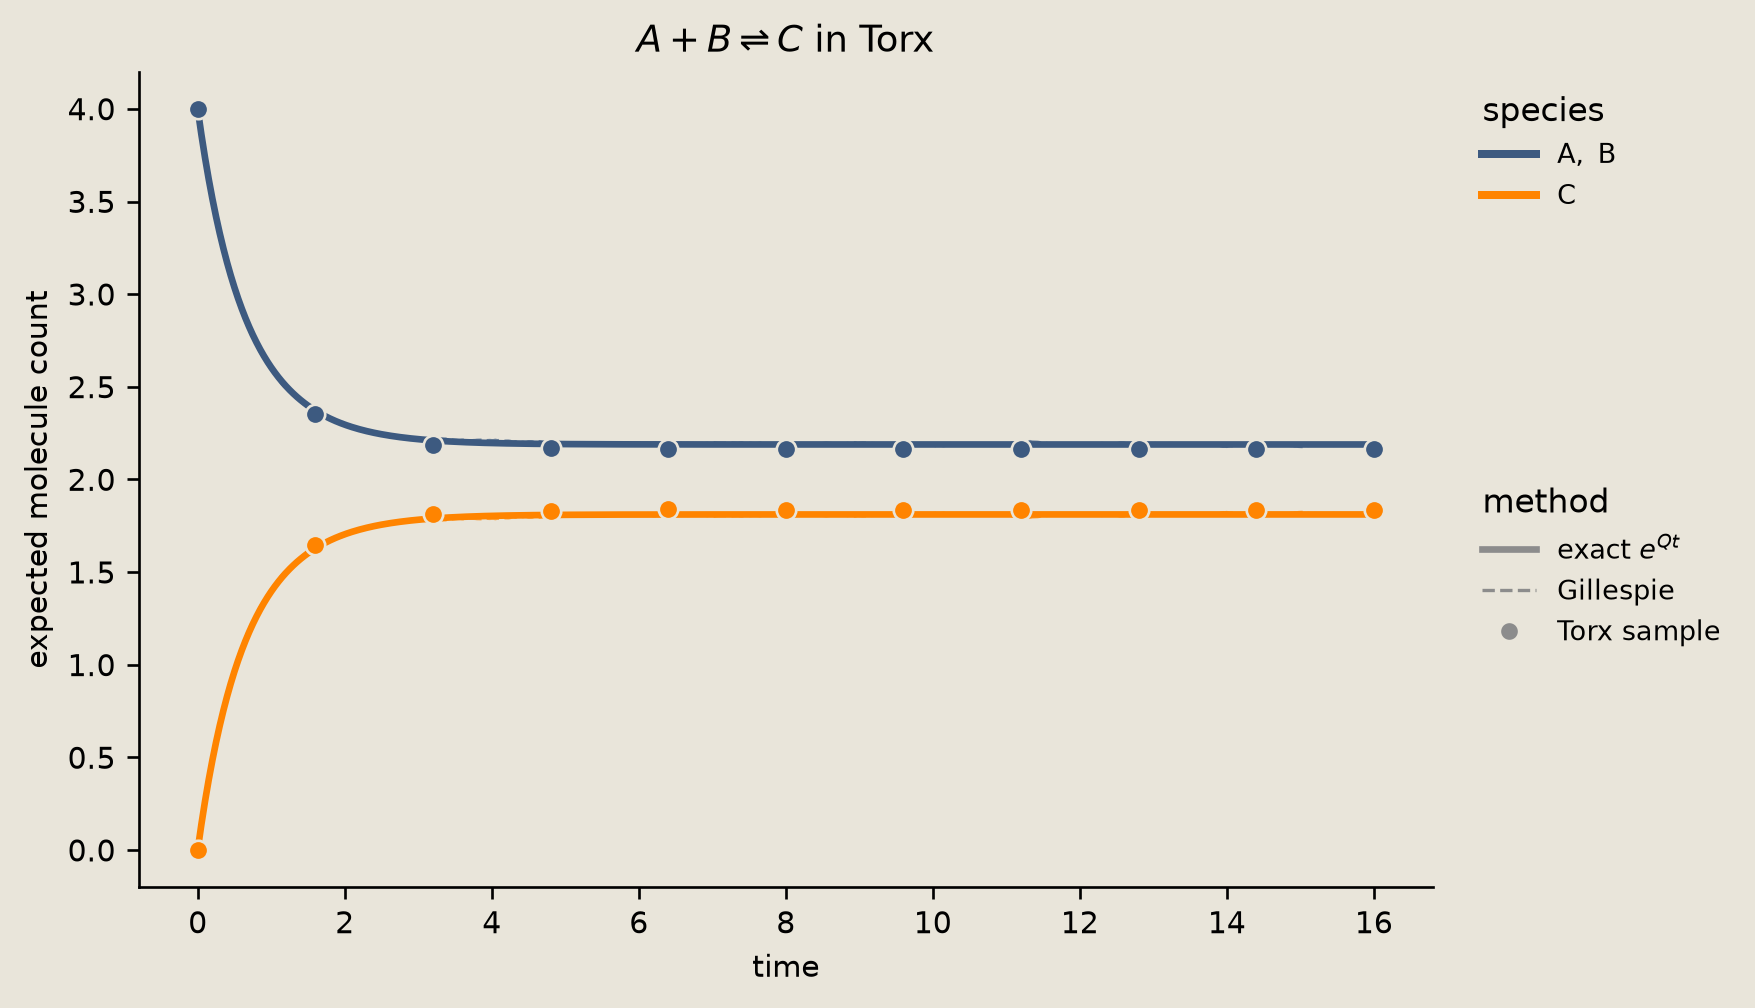

In [27]:
series_b = [
    (r"$\mathrm{A},\ \mathrm{B}$", A, EXACT_COLOR),
    (r"$\mathrm{C}$", C, TORX_COLOR),
]
fig = plot_species_dynamics(
    r"$A + B \rightleftharpoons C$ in Torx",
    times_b, ref_counts_b, gil_counts_b, snapshot_times_b, torx_counts_b, series_b,
)
savefig(fig, "05_binding_equilibrium")

Unlike the irreversible water reaction, the counts do not run to completion. $\mathrm{A}$ and $\mathrm{B}$ start equal and stay equal, because the conservation law $n_{\mathrm{A}} - n_{\mathrm{B}} = 0$ holds along every reachable configuration, so they trace a single curve. Both settle at $n_{\mathrm{A}} = n_{\mathrm{B}} \approx 2.19$ while $n_{\mathrm{C}} \approx 1.81$, the mass-action equilibrium where the forward flux $k_f\,n_{\mathrm{A}}\,n_{\mathrm{B}}$ balances the reverse flux $k_r\,n_{\mathrm{C}}$.

The conserved quantities are now $n_{\mathrm{A}} + n_{\mathrm{C}}$ and $n_{\mathrm{B}} + n_{\mathrm{C}}$. As before, the Torx sample mean matches both references.

In [28]:
cons = {"A+C": np.array([1, 0, 1]), "B+C": np.array([0, 1, 1])}
for i, j, _ in edges_b:
    for w in cons.values():
        assert w @ np.array(configs_b[i]) == w @ np.array(configs_b[j])

torx_vs_exact_b = float(np.max(np.abs(torx_counts_b - ref_counts_b[snapshot_reps_b])))
gil_vs_exact_b = float(np.max(np.abs(gil_counts_b[snapshot_reps_b] - ref_counts_b[snapshot_reps_b])))
assert torx_vs_exact_b < 0.05 and gil_vs_exact_b < 0.05
print(f"conservation (A+C, B+C)        : OK")
print(f"max |Torx - exact|             : {torx_vs_exact_b:.4f}  (< 0.05)")
print(f"max |Gillespie - exact|        : {gil_vs_exact_b:.4f}  (< 0.05)")
print("all checks passed")

conservation (A+C, B+C)        : OK
max |Torx - exact|             : 0.0274  (< 0.05)
max |Gillespie - exact|        : 0.0105  (< 0.05)
all checks passed


## The cost: configuration count

One pbit per configuration means the state space grows with the molecule budget. A single reaction stays linear in the counts, but reactions coupled through a shared species multiply: the configuration count grows as the product of the per-reaction counts.

Count the reachable configurations as the molecule budget grows, first for the single water reaction, then for two reactions that share a species.

In [29]:
def n_reachable(initial, reaction_list):
    rs = [({a: b for a, b in r[0]}, {a: b for a, b in r[1]}) for r in reaction_list]
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        for reac, prod in rs:
            if all(s[k] >= nu for k, nu in reac.items()):
                nxt = list(s)
                for k, nu in reac.items(): nxt[k] -= nu
                for k, nu in prod.items(): nxt[k] += nu
                nxt = tuple(nxt)
                if nxt not in seen: seen.add(nxt); frontier.append(nxt)
    return len(seen)




In [30]:
water = ((( 0, 2), (1, 1)), ((2, 2),))                 # 2 H2 + O2 -> 2 H2O
ammonia = ((( 0, 3), (3, 1)), ((4, 2),))               # N2 + 3 H2 -> 2 NH3
print("one reaction (water), scaling up:")
for k in (2, 4, 8, 16, 32):
    print(f"  H2={2*k:>3}, O2={k:>2}  ->  {n_reachable((2*k, k, 0), [water]):>4} configs")
print("two coupled reactions (water + ammonia, shared H2):")
for k in (2, 4, 8, 16, 32):
    print(f"  H2={6*k:>3}, O2={k:>2}, N2={k:>2}  ->  {n_reachable((6*k, k, 0, k, 0), [water, ammonia]):>4} configs")

one reaction (water), scaling up:
  H2=  4, O2= 2  ->     3 configs
  H2=  8, O2= 4  ->     5 configs
  H2= 16, O2= 8  ->     9 configs
  H2= 32, O2=16  ->    17 configs
  H2= 64, O2=32  ->    33 configs
two coupled reactions (water + ammonia, shared H2):
  H2= 12, O2= 2, N2= 2  ->     9 configs
  H2= 24, O2= 4, N2= 4  ->    25 configs
  H2= 48, O2= 8, N2= 8  ->    81 configs
  H2= 96, O2=16, N2=16  ->   289 configs
  H2=192, O2=32, N2=32  ->  1089 configs


Coupling a second reaction through the shared $\mathrm{H_2}$ multiplies the configuration counts: at the largest budget the water reaction alone reaches 33 configurations, while the joint network reaches $33^2 = 1089$.


## Conclusion

With the configuration-space mapping, a real mass-action reaction network runs as a single-token CTMC and one `PJUMP` per edge reproduces the exact dynamics, validated against both $e^{Qt}$ and Gillespie. The nonlinear propensities live in the per-edge rates.

The catch is the combinatorial growth of the configuration count above, which is why richer encodings than one-hot enumeration become preferable as networks grow. The linear, single-token corner of this construction is a directed [graph random walk](02_random_walks_on_graphs.ipynb) with one walker.

See also:

- [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), the single-token graph-transport corner of this construction.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb), how `SampleSimulator` estimates expectations from bitstrings.

## References

1. Gillespie, D.T. 1977. [*Exact stochastic simulation of coupled chemical reactions*](https://pubs.acs.org/doi/10.1021/j100540a008). J. Phys. Chem. 81(25), 2340-2361. The stochastic simulation algorithm the Torx sample mean is validated against.

